---
# Race analysis notebook
---

In [389]:
import gpxpy, gpxpy.gpx, sys, os
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
from math import radians, sin, cos, sqrt, atan2
from matplotlib.colors import LogNorm

sys.path.insert(0, os.path.join(os.getcwd(), ".."))
import utils

# Thresholds for steepness ---
STEEP_THRESHOLD_SOFT    = 5.0  # Soft Steep
STEEP_THRESHOLD_STRONG  = 13.0 # Hard Steep
STEEP_THRESHOLD_EXTREME = 20.0 # Extreme Steep

MIN_SEGMENT_KM = 0.1
IRREGULARITY_THRESHOLD = 15
WINDOW_SIZE = 15
WINDOW_SIZE_KM = 0.1
SMOOTH_WINDOW = 10 # larger -> smoother

### Race parameters

In [390]:
RACE_NAME = "zegama"

gpx_file_path = os.path.join("data_races", f"{RACE_NAME}.gpx")

### Loading data

In [391]:
with open(gpx_file_path, "r") as gpx_file:
    gpx = gpxpy.parse(gpx_file)

lats, lons, alts = [], [], []
for segment in gpx.tracks[0].segments:
    for point in segment.points:
        lats.append(point.latitude)
        lons.append(point.longitude)
        alts.append(point.elevation if point.elevation is not None else 0.0)
print(f"Loading {len(lats)} points.")

dist, total_dist = [0.0], 0.0
for i in range(1, len(lats)):
    lat1_rad, lat2_rad = radians(lats[i-1]), radians(lats[i])
    lon1_rad, lon2_rad = radians(lons[i-1]), radians(lons[i])
    dlon, dlat = lon2_rad - lon1_rad, lat2_rad - lat1_rad

    # Haversine distance
    a = sin(dlat / 2)**2 + cos(lat1_rad) * cos(lat2_rad) * sin(dlon / 2)**2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))
    dist_segment = utils.R * c

    total_dist += dist_segment
    dist.append(total_dist)

lats, lons, alts, dist = np.array(lats), np.array(lons), np.array(alts), np.array(dist)
elev_gain = np.sum(np.maximum(0, np.diff(alts)))
print(f"\nTotal distance: {total_dist:.2f} km, Elevation gain: {elev_gain:+.2f} m")

delta_alt = np.array([0, *np.diff(alts)])
delta_dist = np.array([0, *np.diff(dist)]) * 1000 

epsilon = 1e-6
delta_dist = np.where(delta_dist > 0.001, delta_dist, epsilon) 

slope = (delta_alt / delta_dist) * 100
slope = np.convolve(slope, np.ones(WINDOW_SIZE)/WINDOW_SIZE, mode="same")
slope = np.clip(slope, -50, 50)

difficulty_score = elev_gain / total_dist
print(f"\nDifficulty score: {difficulty_score:.2f} m/km")

Loading 27507 points.

Total distance: 42.03 km, Elevation gain: +3271.78 m

Difficulty score: 77.84 m/km


### Main plots

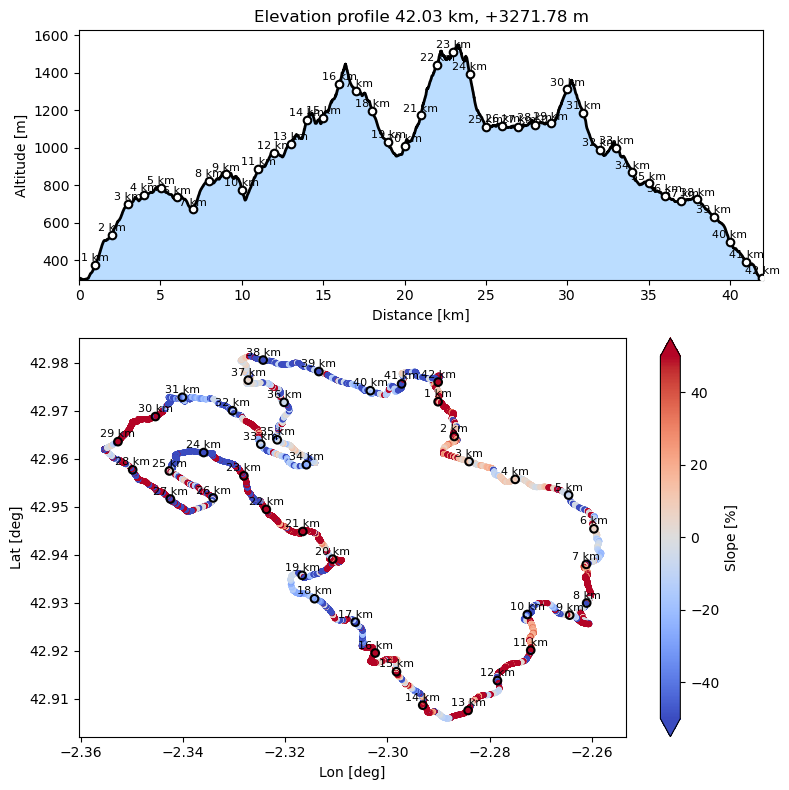

In [392]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), gridspec_kw={"height_ratios": [1, 1.6]})

ax1.plot(dist, alts, color="k", linewidth=2)
ax1.fill_between(dist, alts, color="dodgerblue", alpha=0.3)

for km in range(1, int(total_dist)+1):
    idx = np.searchsorted(dist, km)
    ax1.scatter(dist[idx], alts[idx], s=30, linewidths=1.5, ec="k", fc="w", zorder=10)
    ax1.text(dist[idx], alts[idx]+10, f"{km} km", ha="center", va="bottom", fontsize=8)
    ax2.scatter(lons[idx], lats[idx], s=30, linewidths=1.5, ec="k", fc="none", zorder=10)
    ax2.text(lons[idx], lats[idx]+0.0005, f"{km} km", ha="center", va="bottom", fontsize=8)

sc = ax2.scatter(lons, lats, c=slope, cmap="coolwarm", s=10)
cbar = plt.colorbar(sc, label="Slope [%]", ax=ax2, extend="both")

ax1.set_title(f"Elevation profile {total_dist:.2f} km, {elev_gain:+.2f} m")
ax1.set_xlabel("Distance [km]"); ax1.set_ylabel("Altitude [m]")
ax2.set_xlabel("Lon [deg]"); ax2.set_ylabel("Lat [deg]")
ax1.set_ylim(alts.min()); ax1.set_xlim(0, total_dist)

plt.tight_layout()
plt.savefig(f"./plots/trail_elevation_profile_{RACE_NAME}.png", dpi=300, bbox_inches="tight")
plt.show()

### Irregularity scores

In [393]:
alt_irregularity, bearings = [], []
for i in range(len(dist)):
    start_dist = dist[i] - (WINDOW_SIZE_KM / 2)
    end_dist   = dist[i] + (WINDOW_SIZE_KM / 2)

    start_idx = np.searchsorted(dist, start_dist, side="left")
    end_idx   = np.searchsorted(dist, end_dist, side="right")

    window_alts = alts[start_idx:end_idx]
    if len(window_alts) > 1:
        alt_irreg = np.std(window_alts)
    else:
        alt_irreg = 0.0
    alt_irregularity.append(alt_irreg)
    if end_idx < len(lats):
        lat1_rad = radians(lats[start_idx])
        lon1_rad = radians(lons[start_idx])
        lat2_rad = radians(lats[end_idx-1])
        lon2_rad = radians(lons[end_idx-1])

        dlon = lon2_rad - lon1_rad
        x = sin(dlon) * cos(lat2_rad)
        y = cos(lat1_rad) * sin(lat2_rad) - sin(lat1_rad) * cos(lat2_rad) * cos(dlon)
        initial_bearing = atan2(x, y)
        initial_bearing_deg = (np.degrees(initial_bearing) + 360) % 360
        bearings.append(initial_bearing_deg)
    else:
        bearings.append(bearings[-1] if bearings else 0.0)
bearings = np.array(bearings)
bearing_irregularity = []
for i in range(1, len(bearings)):
    diff = abs(bearings[i] - bearings[i-1])
    diff = min(diff, 360 - diff)
    bearing_irregularity.append(diff)
bearing_irregularity.insert(0, 0.0)

SMOOTH_WINDOW = 10 # larger -> smoother

def _cap_scale_smooth(arr, cap=20.0, scale=100.0, smooth_window=SMOOTH_WINDOW):
    a = np.array(arr, dtype=float)
    a = np.where(a > cap, cap, a)
    maxv = a.max() if a.size else 0.0
    if maxv == 0:
        scaled = np.zeros_like(a)
    else:
        scaled = (a / maxv) * scale
    if smooth_window is None or smooth_window <= 1:
        return scaled
    kernel = np.ones(int(smooth_window)) / float(smooth_window)
    return np.convolve(scaled, kernel, mode="same")

alt_irregularity = _cap_scale_smooth(alt_irregularity, smooth_window=SMOOTH_WINDOW)
bearing_irregularity = _cap_scale_smooth(bearing_irregularity, smooth_window=SMOOTH_WINDOW)

combined_irregularity = alt_irregularity * bearing_irregularity
combined_irregularity = combined_irregularity / combined_irregularity.max() * 100.0

### Irregularity score plots

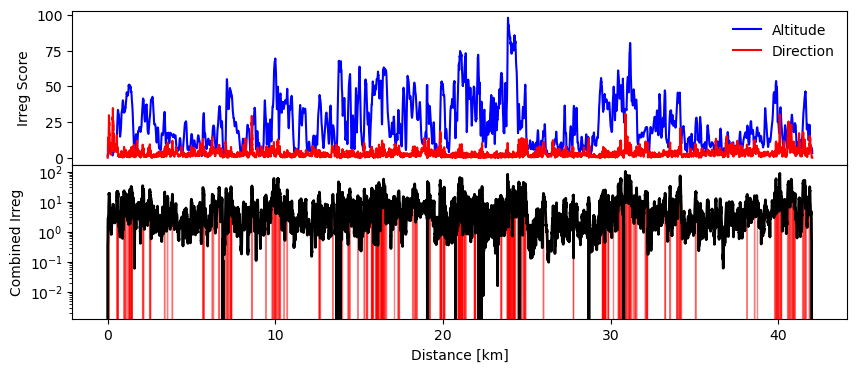

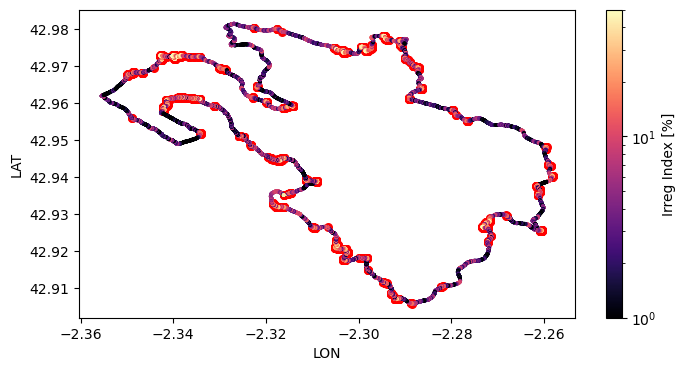

In [394]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 4), gridspec_kw={"height_ratios": [1, 1]})

ax1.plot(dist, alt_irregularity, color="b", label="Altitude")
ax1.plot(dist, bearing_irregularity, color="r", label="Direction")
ax2.plot(dist, combined_irregularity, color="k", linewidth=2.0)
ax2.fill_between(
    dist, combined_irregularity, 0, where=(combined_irregularity >= IRREGULARITY_THRESHOLD), color="red", alpha=0.5, label="High Irreg"
)

ax2.set_yscale("log"); ax2.set_ylabel("Combined Irreg"); ax2.set_xlabel("Distance [km]"); ax1.set_ylabel("Irreg Score")
ax1.legend(frameon=False); plt.subplots_adjust(wspace=0, hspace=0)
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
sc = ax.scatter(lons, lats, c=combined_irregularity, cmap="magma", s=3, norm=LogNorm(vmin=1e0, vmax=50))
fig.colorbar(sc, ax=ax, label="Irreg Index [%]")
high_irreg_indices = np.where(combined_irregularity >= IRREGULARITY_THRESHOLD)[0]
ax.scatter(lons[high_irreg_indices], lats[high_irreg_indices], c="red", s=30, label="High Irreg", zorder=-10)

ax.set_xlabel("LON"); ax.set_ylabel("LAT")
plt.savefig(f"./plots/irregularity_track_{RACE_NAME}.png", dpi=300, bbox_inches="tight")
plt.show()

## Segmenting the race

In [395]:
def add_to_dict(d, seg):
    direction, intensity, s, e = seg
    if direction == "flat":
        d["flat"].append((s, e))
    else:
        d.setdefault(direction, {}).setdefault(intensity, []).append((s, e))

def get_attrs(slope_val):
    if abs(slope_val) < 0.5: return "flat", "soft"
    direction = "uphill" if slope_val >= 0.5 else "downhill"
    s = abs(slope_val)
    if s >= STEEP_THRESHOLD_EXTREME:
        intensity = "extreme"
    elif s >= STEEP_THRESHOLD_STRONG:
        intensity = "strong"
    else:
        intensity = "soft"
    return direction, intensity

# 1. Revised Initial Segmentation (Gapless)
dict_segments = {'uphill': {}, 'downhill': {}, 'flat': []}
current = None

for i in range(1, len(dist)):
    # Instead of 'continue', we assign 'irregular' points to the previous segment's type 
    # OR a default 'flat' type to keep the line continuous.
    if combined_irregularity[i] >= IRREGULARITY_THRESHOLD:
        dirn, intens = (current[0], current[1]) if current else ('flat', 'soft')
    else:
        dirn, intens = get_attrs(slope[i])

    if current and (dirn, intens) == (current[0], current[1]):
        current = (dirn, intens, current[2], dist[i])
    else:
        if current: add_to_dict(dict_segments, current)
        # Bridge the distance gap by starting exactly where the last one ended (dist[i-1])
        current = (dirn, intens, current[3] if current else dist[i-1], dist[i])

if current: add_to_dict(dict_segments, current)

# 2. Flatten and Merge Adjacents
raw = []
for d in ["uphill", "downhill"]:
    for intensity, segments in dict_segments.get(d, {}).items():
        raw.extend([(d, intensity, s, e) for s, e in segments])
raw.extend([("flat", "soft", s, e) for s, e in dict_segments["flat"]])
raw.sort(key=lambda x: x[2])

merged = []
for seg in raw:
    if merged and seg[:2] == merged[-1][:2] and abs(seg[2] - merged[-1][3]) <= 1e-6:
        merged[-1] = (*merged[-1][:3], seg[3])
    else:
        merged.append(seg)

# 3. Collapse Short Segments
i = 0
while i < len(merged):
    dirn, intens, s, e = merged[i]
    if (e - s) >= MIN_SEGMENT_KM or len(merged) == 1:
        i += 1; continue

    # Determine neighbor to merge into
    if i > 0 and i < len(merged) - 1:
        prev_len, next_len = merged[i-1][3]-merged[i-1][2], merged[i+1][3]-merged[i+1][2]
        idx = i - 1 if prev_len >= next_len else i + 1
    else:
        idx = i - 1 if i > 0 else i + 1
    
    # Update neighbor and pop current
    m_dir, m_int, m_s, m_e = merged[idx]
    merged[idx] = (m_dir, m_int, min(s, m_s), max(e, m_e))
    merged.pop(i)
    i = max(0, i - 1)

# 4. Final Rebuild
dict_segments = {"uphill": {}, "downhill": {}, "flat": []}
for seg in merged: add_to_dict(dict_segments, seg)

# 5. Flatten segments and define visual styles
segments = [("flat", "soft", s[0], s[1]) for s in dict_segments.get("flat", [])]
for d in ["uphill", "downhill"]:
    for intensity, slist in dict_segments.get(d, {}).items():
        segments.extend([(d, intensity, s, e) for s, e in slist])

COLOR_MAP = {
    "flat":    {"soft":"#2ca02c"},
    "uphill":  {"soft":"#ffd86b", "strong":"#ff8c42", "extreme":"#d62728", "climb":"#8b0000"},
    "downhill":{"soft":"#8fd3ff", "strong":"#4aa3e0", "extreme":"#2a5aa0", "climb":"#1a3e5c"},
}

### Segments plot of the race

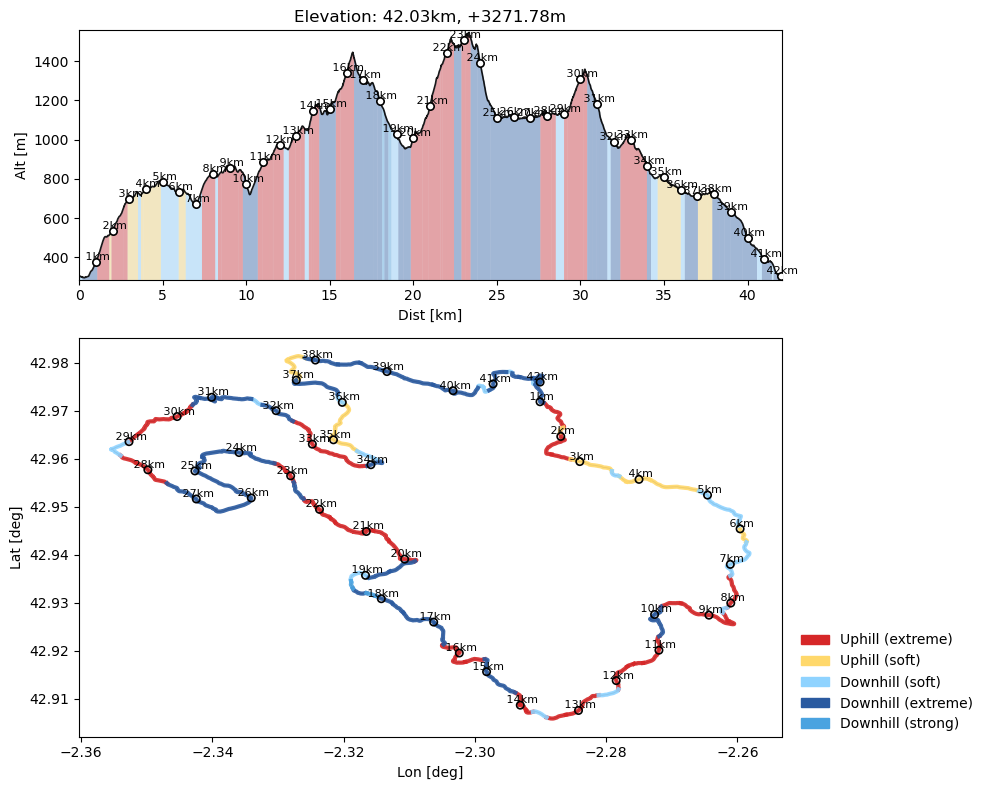

In [396]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), gridspec_kw={"height_ratios": [1, 1.6]})
ax1.fill_between(dist, alts, color="lightsteelblue", alpha=0.25)
ax1.plot(dist, alts, "k", lw=1.2, alpha=0.9)
ax2.plot(lons, lats, "k", lw=0.8, alpha=0.6)

legend_patches = {}
for dr, intens, s_km, e_km in segments:
    si, ei = np.searchsorted(dist, [s_km, e_km]).clip(0, len(dist)-1)
    color = COLOR_MAP.get(dr, {}).get(intens, "#666666")
    
    ax1.fill_between(dist[si:ei+1], alts[si:ei+1], color=color, alpha=0.38, lw=0)
    ax2.plot(lons[si:ei+1], lats[si:ei+1], color=color, lw=3, alpha=0.9)
    
    label = f"{dr.title()} ({intens})"
    if label not in legend_patches:
        legend_patches[label] = Patch(color=color, label=label)

for km in range(1, int(total_dist) + 1):
    idx = np.searchsorted(dist, km)
    for ax, x, y, style in zip([ax1, ax2], [dist, lons], [alts, lats], ["w", "none"]):
        ax.scatter(x[idx], y[idx], s=28, lw=1.2, ec="k", fc=style, zorder=10)
        ax.text(x[idx], y[idx], f" {km}km", fontsize=8, va="bottom", ha="center")

ax2.legend(handles=list(legend_patches.values()), loc=(1.02, 0), frameon=False)
ax1.set(title=f"Elevation: {total_dist:.2f}km, {elev_gain:+.2f}m", ylabel="Alt [m]", xlabel="Dist [km]")
ax1.set_ylim(alts.min()-10, alts.max()+10); ax1.set_xlim(0, total_dist); ax2.set(xlabel="Lon [deg]", ylabel="Lat [deg]")
plt.tight_layout()

plt.savefig(f"./plots/segments_{RACE_NAME}.png", dpi=300, bbox_inches="tight")
plt.show()

### And race terrain distribution chart

In [397]:
# Build totals from segments (include 'climb')
totals = {}
for d, it, s_km, e_km in segments:
    totals.setdefault(d, {}).setdefault(it, 0.0)
    totals[d][it] += float(e_km - s_km)

# Flatten items and compute total_km
items = [(d, it, v) for d in totals for it, v in totals[d].items()]
total_km = sum(v for _, _, v in items)

# Prepare slices, colors and labels (include climb)
slices = [v for d, it, v in items if v > 0]
slice_colors = [COLOR_MAP.get(d, {}).get(it, "#666666") for d, it, v in items if v > 0]

# Build segment stats if not present (safe to overwrite)
segment_stats = []
for dr, intens, s_km, e_km in segments:
    si, ei = np.searchsorted(dist, [s_km, e_km]).clip(0, len(dist)-1)
    avg_slope = float(np.mean(slope[si:ei+1]))
    segment_stats.append({
        "direction": dr,
        "intensity": intens,
        "start_km": float(s_km),
        "end_km": float(e_km),
        "length_km": float(e_km - s_km),
        "avg_slope": avg_slope,
    })

labels_pie_with_slope = []
for d, it, v in items:
    if v <= 0:
        continue
    avg_s = next((s["avg_slope"] for s in segment_stats if s["direction"] == d and s["intensity"] == it), 0.0)
    pct = (v / total_km * 100) if total_km > 0 else 0.0
    labels_pie_with_slope.append(f"{d.title()} {it}\n{v:.2f} km\n({pct:.1f}%)\nAvg slope: {avg_s:.1f}%")

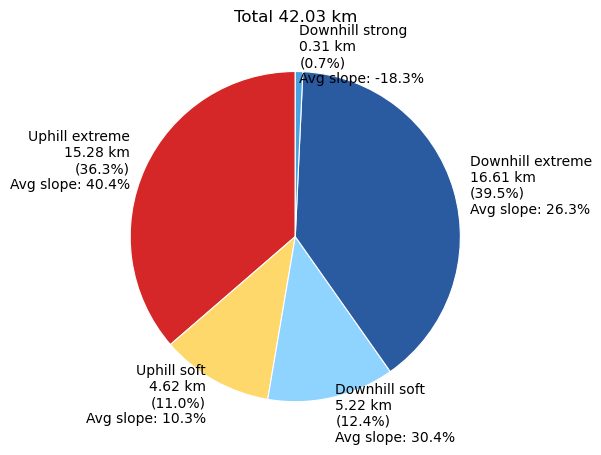

In [398]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(slices, labels=labels_pie_with_slope, colors=slice_colors, startangle=90,
       wedgeprops={"linewidth": 0.8, "edgecolor": "white"})
ax.set_title(f"Total {total_km:.2f} km")
plt.tight_layout()
plt.savefig(f"./plots/terrain_distribution_{RACE_NAME}.png", dpi=300, bbox_inches="tight")
plt.show()